In [1]:
import sys
sys.path.append('../src')
import utils2
import pandas as pd
import s3fs
import geopandas as gpd

arbres = pd.read_csv("https://www.data.gouv.fr/api/1/datasets/r/60433484-f30e-44ef-a362-e5553a9b7a42", sep = ";")
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})

MY_BUCKET = "raphcrre"
PATH_IRIS = f"{MY_BUCKET}/diffusion/projet_arbres/iris.gpkg"

with fs.open(PATH_IRIS, 'rb') as f:
    iris_france = gpd.read_file(f)

iris = iris_france[iris_france['code_insee'].astype(str).str.startswith('75')].copy()
df_arbres = utils2.jointure_arbres_iris(arbres, iris)



/opt/python/lib/python3.13/site-packages/pyogrio/raw.py:200: RuntimeWarning: File /vsimem/pyogrio_5dc7c3f8f335411bbcbb9fe496a24be8 has GPKG application_id, but non conformant file extension
  return ogr_read(


In [8]:
arbres


,IDBASE,TYPE EMPLACEMENT,DOMANIALITE,ARRONDISSEMENT,COMPLEMENT ADRESSE,LIEU / ADRESSE,IDEMPLACEMENT,LIBELLE FRANCAIS,GENRE,ESPECE,VARIETE OUCULTIVAR,CIRCONFERENCE (cm),HAUTEUR (m),STADE DE DEVELOPPEMENT,REMARQUABLE,geo_point_2d,lat,lon
0,222943,Arbre,Alignement,PARIS 19E ARRDT,NaN,BOULEVARD MACDONALD,000501006,Platane,Platanus,x hispanica,NaN,85,12,Adulte,NON,"48.89876969235843, 2.380028303025838",48.898770,2.380028
1,105919,Arbre,Jardin,PARIS 13E ARRDT,Massif 15 / ouest laboratoire,PARC DE CHOISY / 1 RUE GEORGE EASTMAN,000803011,Frêne,Fraxinus,excelsior,NaN,215,18,Mature,NON,"48.828098147789895, 2.358838270920697",48.828098,2.358838
2,128441,Arbre,Jardin,PARIS 15E ARRDT,POURTOUR N°3,SQUARE DU CLOS FEUQUIERES / 30 RUE DESNOUETTES,000103007,Sorbier,Sorbus,latifolia,''Henk Vink'',25,6,Jeune (arbre),NON,"48.837207280503826, 2.2906077396803024",48.837207,2.290608
3,286198,Arbre,Alignement,PARIS 10E ARRDT,76,BOULEVARD DE STRASBOURG,001202003,Platane,Platanus,x hispanica,NaN,156,20,Adulte,NON,"48.87574004636556, 2.3581697822623613",48.875740,2.358170
4,319506,Arbre,Jardin,PARIS 10E ARRDT,NaN,JARDIN VILLEMIN - MAHSA JINA AMINI / 8 RUE DES...,000205004,Charme,Carpinus,betulus,NaN,25,4,Jeune (arbre),NON,"48.874760908852686, 2.3620857806135063",48.874761,2.362086
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217747,301951,Arbre,Alignement,PARIS 13E ARRDT,NaN,AVENUE D ITALIE,000903005,Orme,Ulmus,minor,NaN,135,20,Adulte,NON,"48.82542270913384, 2.357717555386741",48.825423,2.357718
217748,306738,Arbre,Jardin,PARIS 8E ARRDT,NaN,PARC MONCEAU / 1 PLACE DE LA REPUBLIQUE DOMINI...,SE0101015,Erable,Acer,platanoides,''Schwedleri'',171,15,Adulte,NON,"48.87902526025176, 2.3094743430415194",48.879025,2.309474
217749,2006655,Arbre,Alignement,BOIS DE VINCENNES,NaN,ROUTE SAINT HUBERT,000602030,Noyer,Juglans,nigra,NaN,115,15,Adulte,NON,"48.82815149480281, 2.4369801049984194",48.828151,2.436980
217750,2023223,Arbre,Jardin,PARIS 15E ARRDT,NaN,PROMENADE DU QUAI ANDRE CITROEN / 13 QUAI AND...,000105002,Magnolia,Magnolia,stellata,NaN,45,7,Adulte,NON,"48.848128903800884, 2.2801445622645646",48.848129,2.280145


In [10]:
# On suppose que tes colonnes s'appellent 'CIRCONFERENCE_CM' et 'HAUTEUR_M'
# On ajoute aussi le comptage pour avoir le nombre d'arbres par IRIS
iris_for_clustering = df_arbres.groupby('cleabs').agg({
    'CIRCONFERENCE (cm)': ['mean', 'std'], # Moyenne et robustesse de la taille
    'HAUTEUR (m)': ['mean', 'max'],        # Hauteur moyenne et présence de grands arbres
    'IDBASE': 'count'                    # Nombre total d'arbres
}).reset_index()

# On renomme les colonnes pour qu'elles soient plus simples à manipuler
iris_for_clustering.columns = [
    'cleabs', 'circ_moyenne', 'circ_std', 
    'haut_moyenne', 'haut_max', 'nb_arbres'
]

# Optionnel : Remplacer les NaN (IRIS avec 1 seul arbre où l'écart-type 'std' sera NaN)
iris_for_clustering = iris_for_clustering.fillna(0)


iris_for_clustering


,cleabs,circ_moyenne,circ_std,haut_moyenne,haut_max,nb_arbres
0,IRIS____0000000751010101,85.036232,47.551341,8.710145,20,138
1,IRIS____0000000751010102,105.770492,65.606248,9.606557,22,61
2,IRIS____0000000751010103,85.106383,54.068087,6.851064,20,47
3,IRIS____0000000751010199,97.547131,77.913854,10.165984,28,488
4,IRIS____0000000751010201,66.768293,30.019135,6.951220,15,164
...,...,...,...,...,...,...
968,IRIS____0000000751208022,111.726744,65.039626,11.168605,25,172
969,IRIS____0000000751208023,85.350575,55.776164,8.091954,20,174
970,IRIS____0000000751208024,76.774194,54.369832,7.943548,20,124
971,IRIS____0000000751208025,51.238095,43.359422,6.309524,15,42


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Sélection des colonnes numériques uniquement
X = iris_for_clustering.drop(columns=['cleabs'])

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Application du K-Means (testons avec 4 groupes pour commencer)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
iris_for_clustering['cluster'] = kmeans.fit_predict(X_scaled)


In [16]:
# Voir les caractéristiques moyennes de chaque groupe
# On ne garde que les colonnes numériques pour le calcul de la moyenne
stats_clusters = iris_for_clustering.groupby('cluster').mean(numeric_only=True)

print(stats_clusters)


         circ_moyenne   circ_std  haut_moyenne    haut_max    nb_arbres
cluster                                                                
0           68.107703  40.133308      8.026875   18.252546   127.533605
1           97.652324  56.307790     11.378142   23.597403   178.510823
2           91.914147  63.798519      9.266452   30.533333  3038.933333
3           86.980657  55.433798     11.022908  179.000000   262.000000


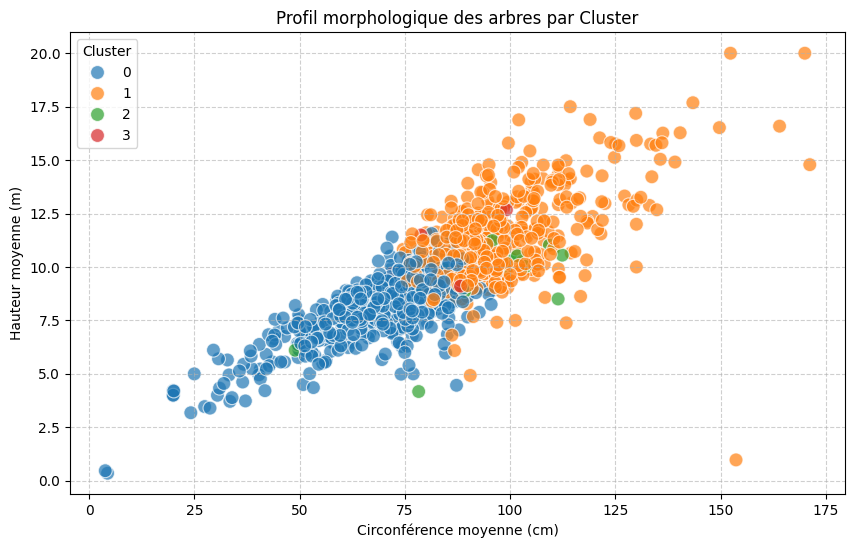

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# On trace la hauteur en fonction de la circonférence, colorée par cluster
sns.scatterplot(data=iris_for_clustering, 
                x='circ_moyenne', 
                y='haut_moyenne', 
                hue='cluster', 
                palette='tab10', 
                s=100, alpha=0.7)

plt.title('Profil morphologique des arbres par Cluster')
plt.xlabel('Circonférence moyenne (cm)')
plt.ylabel('Hauteur moyenne (m)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


<Axes: >

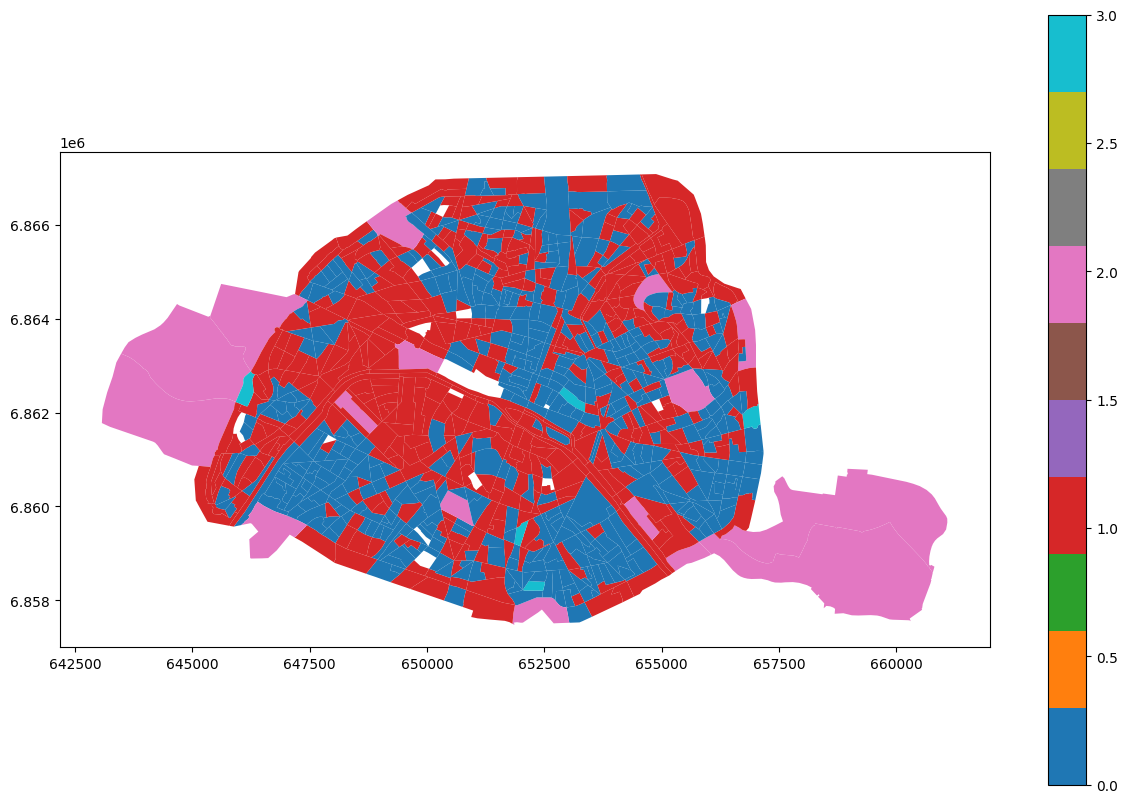

In [19]:
# Fusion avec la géométrie des IRIS
# On utilise 'cleabs' ou 'code_iris' selon ta colonne commune
map_df = iris.merge(iris_for_clustering[['cleabs', 'cluster']], 
                    left_on='cleabs', # ou la colonne correspondante dans 'iris'
                    right_on='cleabs', 
                    how='left')

# Affichage
map_df.plot(column='cluster', cmap='tab10', legend=True, figsize=(15, 10))



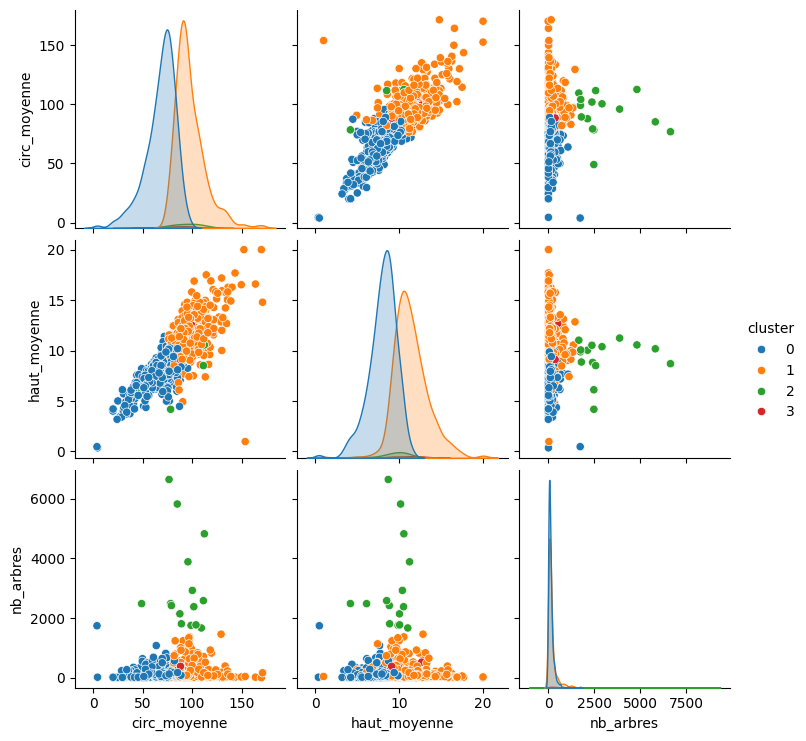

In [20]:
# On sélectionne les colonnes numériques et le cluster
cols_to_plot = ['circ_moyenne', 'haut_moyenne', 'nb_arbres', 'cluster']
sns.pairplot(iris_for_clustering[cols_to_plot], hue='cluster', palette='tab10', diag_kind='kde')
plt.show()
